In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# =========================
# 1. Load data
# =========================
df = pd.read_csv("features_subset_df.csv")

# Drop user_id if it exists
X = df.drop(columns=["user_id"], errors="ignore")

# Convert boolean columns to int
bool_cols = X.select_dtypes(include=["bool"]).columns
for col in bool_cols:
    X[col] = X[col].astype(int)

# One-hot encode categorical columns
cat_cols = X.select_dtypes(include=["object"]).columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Fill missing values if any
X = X.fillna(0)

C:\Users\winni\AppData\Local\Temp\ipykernel_23056\315327182.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns


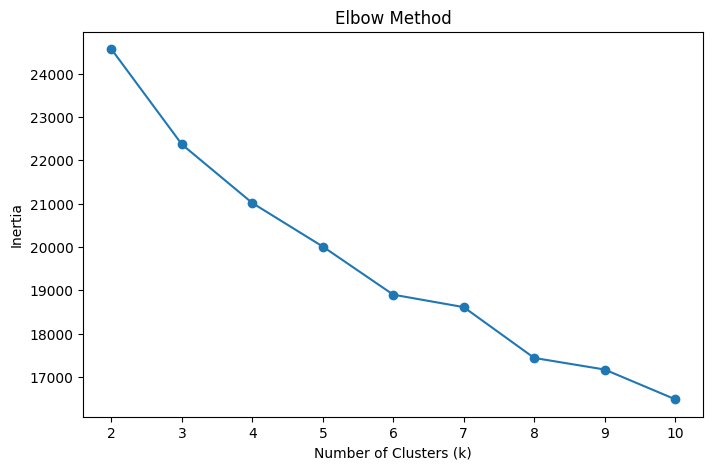

In [29]:
# =========================
# 2. Scale features
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# =========================
# 3. Elbow Method
# =========================
k_range = range(2, 11)
inertia_values = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

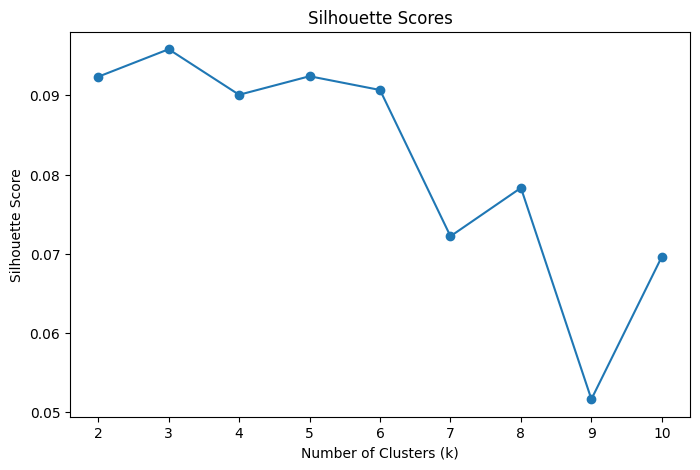

k = 2, silhouette score = 0.0923
k = 3, silhouette score = 0.0958
k = 4, silhouette score = 0.0901
k = 5, silhouette score = 0.0924
k = 6, silhouette score = 0.0907
k = 7, silhouette score = 0.0722
k = 8, silhouette score = 0.0783
k = 9, silhouette score = 0.0516
k = 10, silhouette score = 0.0696


In [30]:
# =========================
# 4. Silhouette Scores
# =========================
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")
plt.show()

for k, score in zip(k_range, silhouette_scores):
    print(f"k = {k}, silhouette score = {score:.4f}")

In [31]:
# =========================
# 5. Final K-means
# =========================
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df["cluster"] = cluster_labels


# =========================
# 6. Cluster sizes
# =========================
print("\nCluster counts:")
print(df["cluster"].value_counts().sort_index())


Cluster counts:
cluster
0      7
1    119
2    112
Name: count, dtype: int64


C:\Users\winni\AppData\Local\Temp\ipykernel_23056\2841943276.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["cluster"] = cluster_labels


In [32]:
# =========================
# 7. Cluster profile
# =========================
X_with_cluster = X.copy()
X_with_cluster["cluster"] = cluster_labels

cluster_profile = X_with_cluster.groupby("cluster").mean()
print("\nCluster profile:")
print(cluster_profile)

cluster_profile_std = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()


# =========================
# 8. Top features per cluster
# =========================
for c in cluster_profile.index:
    print(f"\nCluster {c} - Top features:")
    print(cluster_profile.loc[c].sort_values(ascending=False).head(10))


Cluster profile:
         temporal_peak_hour  temporal_night_ratio  temporal_h_dist_0  \
cluster                                                                
0                 15.142857              0.100637           0.026048   
1                 16.193277              0.097615           0.024345   
2                 13.357143              0.237105           0.047157   

         temporal_h_dist_1  temporal_h_dist_2  temporal_h_dist_3  \
cluster                                                            
0                 0.018863           0.020096           0.015003   
1                 0.018788           0.015080           0.012652   
2                 0.041360           0.040417           0.039897   

         temporal_h_dist_4  temporal_h_dist_5  temporal_h_dist_6  \
cluster                                                            
0                 0.010539           0.010089           0.021391   
1                 0.012742           0.014007           0.017046   
2       

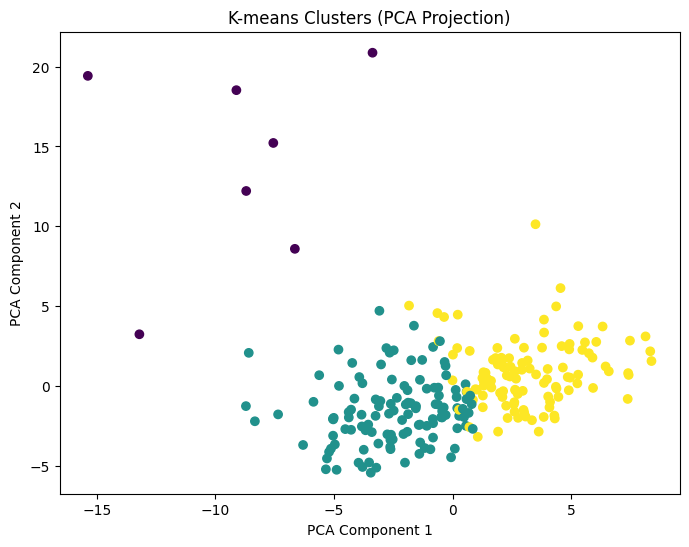

In [33]:
# =========================
# 9. PCA visualization
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-means Clusters (PCA Projection)")
plt.show()

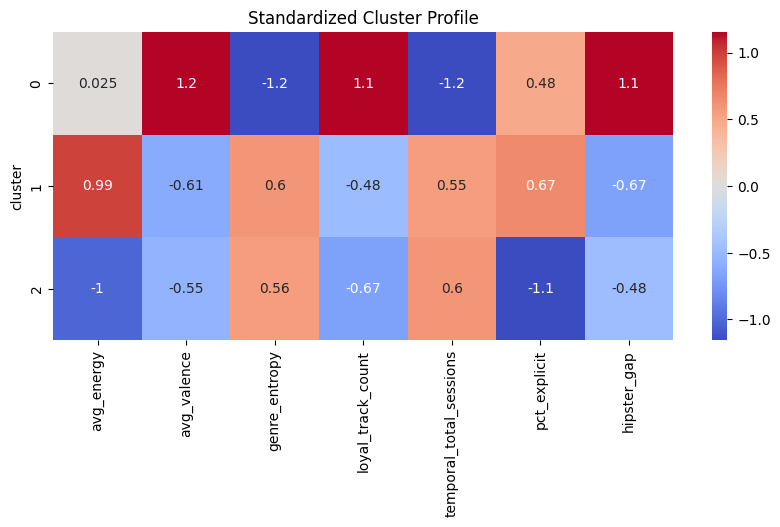

In [34]:
# =========================
# 10. Selected-feature heatmap
# =========================
important_features = [
    "avg_energy",
    "avg_valence",
    "genre_entropy",
    "loyal_track_count",
    "temporal_total_sessions",
    "pct_explicit",
    "hipster_gap"
]

available_features = [f for f in important_features if f in cluster_profile_std.columns]

plt.figure(figsize=(10, 4))
sns.heatmap(cluster_profile_std[available_features], cmap="coolwarm", center=0, annot=True)
plt.title("Standardized Cluster Profile")
plt.show()


# =========================
# 11. Save results
# =========================
df.to_csv("features_subset_with_clusters.csv", index=False)
cluster_profile.to_csv("cluster_profile.csv")
cluster_profile_std.to_csv("cluster_profile_standardized.csv")